In [20]:
import pandas as pd 
load = pd.read_csv('C:\\projects\\retail-sales-analysis\\notebooks\\train.csv\\train.csv')
load.info()
load.head()
load.isnull().sum()
load.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

np.int64(0)

postal code is in float.As we know postal code isn't in float
Postal codes should usually be treated as text, not numbers, because they are identifiers and may have leading zeros. 

In [18]:
load['Postal Code'] = load['Postal Code'].astype('string').fillna('0')
load['Postal Code'] = load['Postal Code'].str.replace(r'\.0$', '', regex=True)
load['Postal Code'].head()

0    42420
1    42420
2    90036
3    33311
4    33311
Name: Postal Code, dtype: string

In [ ]:
load['Postal Code'] = load['Postal Code'].astype('string').fillna('0')
load.info()

In [24]:
load.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9800 non-null   string 
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(1), int6

In [26]:
load['Order Date'] = pd.to_datetime(load['Order Date'], dayfirst=True, errors='coerce')
load['Ship Date'] = pd.to_datetime(load['Ship Date'], dayfirst=True, errors='coerce')
load = load.drop_duplicates()
load.columns = load.columns.str.strip().str.replace(' ', '_')

dayfirst=True tells pandas that the first part is the day.
errors='coerce' will turn bad values into NaT instead of crashing.
pandas is reading your dates as month/day/year, but your values are day/month/year.




In [27]:
load.to_csv('../data/cleaned_sales.csv', index=False)


In [28]:
load.isnull().sum()

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
dtype: int64

In [30]:
load.groupby('Category')['Sales'].sum().sort_values(ascending=False)
load.groupby('Region')['Sales'].sum()
load['Order_Date'].dt.to_period('M').value_counts().sort_index()

Order_Date
2015-01     77
2015-02     46
2015-03    154
2015-04    130
2015-05    121
2015-06    131
2015-07    142
2015-08    146
2015-09    267
2015-10    159
2015-11    306
2015-12    274
2016-01     57
2016-02     64
2016-03    128
2016-04    159
2016-05    143
2016-06    129
2016-07    136
2016-08    158
2016-09    285
2016-10    164
2016-11    321
2016-12    311
2017-01     89
2017-02     83
2017-03    161
2017-04    168
2017-05    221
2017-06    196
2017-07    196
2017-08    175
2017-09    349
2017-10    192
2017-11    366
2017-12    338
2018-01    143
2018-02    104
2018-03    237
2018-04    200
2018-05    240
2018-06    235
2018-07    223
2018-08    214
2018-09    453
2018-10    294
2018-11    456
2018-12    459
Freq: M, Name: count, dtype: int64

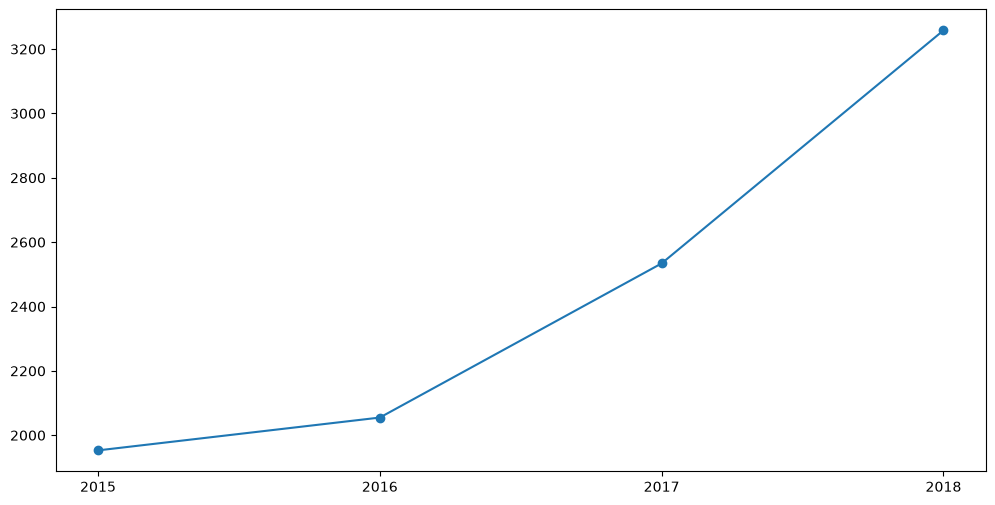

In [34]:
import matplotlib.pyplot as plt
Order_Date = load['Order_Date'].dt.to_period('Y').value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.plot(Order_Date.index.astype(str), Order_Date, marker='o')

In [ ]:
load['Sales'].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64